In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Dates management
import datetime

# Visualization library
import altair as alt
import matplotlib.pyplot as plt

# Data manipulation library
import pandas as pd
import matplotlib.pyplot as plt

# Enable Altair to display all rows of data
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [4]:
df_person_fix = pd.read_pickle("datap/df_person_fix.pkl")
df_bio=pd.read_pickle("datap/df_bio.pkl")
df_visit=pd.read_pickle("datap/df_visit.pkl")
df_condition=pd.read_pickle("datap/df_condition.pkl")   

In [5]:
df_bio.info()
df_bio.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   measurement_id        6188 non-null   float64       
 1   visit_occurrence_id   6188 non-null   float64       
 2   measurement_datetime  6188 non-null   datetime64[ns]
 3   concept_source_value  6188 non-null   object        
 4   transformed_value     6188 non-null   float64       
 5   transformed_unit      6188 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 290.2+ KB


,measurement_id,visit_occurrence_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,85402828.0,87578820.0,2022-05-06,crp,4.53,mg/L
1,89452956.0,82594821.0,2024-10-23,hb,14.18,g/dL
2,88918901.0,87469572.0,2020-02-23,hb,12.31,g/dL
3,86302942.0,88399883.0,2020-02-28,hb,12.04,g/dL
4,86607398.0,86752406.0,2025-08-28,crp,3.86,mg/L


In [6]:

df_bio["concept_source_value"].value_counts()


concept_source_value
crp     1547
hb      1547
bmi     1547
urea    1547
Name: count, dtype: int64

In [7]:
df_bio["transformed_unit"].value_counts()

transformed_unit
mg/L        1547
g/dL        1547
kg.cm^-2    1547
mmol/L      1547
Name: count, dtype: int64

In [8]:
measurement_summary = df_bio.groupby("measurement_datetime", as_index=False).visit_occurrence_id.count()

In [9]:
alt.Chart(measurement_summary).mark_bar(size=1).encode(
    alt.X('measurement_datetime:T', scale=alt.Scale(padding=5)),
    y='visit_occurrence_id:Q'
)

alt.Chart(...)

In [10]:
df_dedup_det = pd.read_pickle('datap/df_dedup_deterministic.pkl')
df_dedup_det.info()
df_dedup_det.head()

<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 9 to 28
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   unique_person_id  36 non-null     float64
 1   person_id         36 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 864.0 bytes


,unique_person_id,person_id
9,84763748.0,82185488
36,81299393.0,87690370
29,81076351.0,81292219
0,83290919.0,86711549
0,89552692.0,80057927


In [11]:
# Outer Join
df_person_dedup_det = pd.merge(df_person_fix, df_dedup_det, on = 'person_id', how = 'outer')

# Complete the unique_person_id column
df_person_dedup_det['unique_person_id'] = df_person_dedup_det['unique_person_id'].fillna(df_person_dedup_det['person_id'])

# Only keep one row per patient
df_person_dedup_det = df_person_dedup_det.drop_duplicates(['unique_person_id'], keep = 'first')

In [12]:
print(f"We have {df_person_dedup_det.unique_person_id.nunique()} unique patient ids in this dataset when using the determinist algorithm.")

We have 1494 unique patient ids in this dataset when using the determinist algorithm.


In [13]:
df_bio_fix=pd.merge(df_visit,df_bio,on="visit_occurrence_id",how="inner")

In [14]:
df_bio_fix.info()
df_bio_fix.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_occurrence_id   6188 non-null   float64       
 1   care_site_id          6188 non-null   object        
 2   visit_start_datetime  6188 non-null   datetime64[ns]
 3   visit_end_datetime    6184 non-null   datetime64[ns]
 4   visit_source_value    6188 non-null   object        
 5   person_id             6188 non-null   float64       
 6   measurement_id        6188 non-null   float64       
 7   measurement_datetime  6188 non-null   datetime64[ns]
 8   concept_source_value  6188 non-null   object        
 9   transformed_value     6188 non-null   float64       
 10  transformed_unit      6188 non-null   object        
dtypes: datetime64[ns](3), float64(4), object(4)
memory usage: 531.9+ KB


,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,81228660.0,2020-01-24,crp,4.53,mg/L
1,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,89065276.0,2020-01-24,urea,3.71,mmol/L
2,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,85894139.0,2020-01-24,bmi,27.84,kg.cm^-2
3,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,85641747.0,2020-01-24,hb,11.04,g/dL
4,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0,85453397.0,2020-02-25,hb,15.00,g/dL


In [15]:
df_bio_fix_final = pd.merge(df_person_dedup_det, df_bio_fix, on = 'person_id', how = 'inner')


In [16]:
df_bio_fix_final.info()
df_bio_fix_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976 entries, 0 to 5975
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   birth_datetime        5976 non-null   datetime64[ns]
 1   death_datetime        3276 non-null   datetime64[ns]
 2   gender_source_value   5976 non-null   object        
 3   cdm_source            5976 non-null   object        
 4   person_id             5976 non-null   float64       
 5   unique_person_id      5976 non-null   float64       
 6   visit_occurrence_id   5976 non-null   float64       
 7   care_site_id          5976 non-null   object        
 8   visit_start_datetime  5976 non-null   datetime64[ns]
 9   visit_end_datetime    5972 non-null   datetime64[ns]
 10  visit_source_value    5976 non-null   object        
 11  measurement_id        5976 non-null   float64       
 12  measurement_datetime  5976 non-null   datetime64[ns]
 13  concept_source_val

,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id,unique_person_id,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,84366354.0,2022-02-19,crp,4.47,mg/L
1,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,83248298.0,2022-02-19,bmi,21.79,kg.cm^-2
2,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,81724471.0,2022-02-19,urea,3.85,mmol/L
3,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,80756786.0,2022-02-19,hb,13.10,g/dL
4,1951-12-31,2024-07-28,female,EHR 1,80021799.0,80021799.0,80105823.0,Hopital M.Bres,2024-07-24,2024-07-28,Hospitalisés,86628185.0,2024-07-24,bmi,24.92,kg.cm^-2


In [17]:
df_bio_final = df_bio_fix_final.to_pickle("datap/df_bio_fix_final.pkl")

In [18]:
#df_analyse=pd.merge(df_person_fix, df_bio_fix_final, on = 'person_id', how = 'inner')
df_analyse = pd.merge(df_condition, df_bio_fix_final, on='person_id', how='inner', suffixes=('', '_drop'))
df_analyse = df_analyse.drop(columns=[col for col in df_analyse.columns if col.endswith('_drop')])


In [19]:
df_analyse.info()
df_analyse.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8308 entries, 0 to 8307
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   visit_occurrence_id      8308 non-null   float64       
 1   person_id                8308 non-null   float64       
 2   condition_occurrence_id  8308 non-null   float64       
 3   condition_source_value   8308 non-null   object        
 4   birth_datetime           8308 non-null   datetime64[ns]
 5   death_datetime           4576 non-null   datetime64[ns]
 6   gender_source_value      8308 non-null   object        
 7   cdm_source               8308 non-null   object        
 8   unique_person_id         8308 non-null   float64       
 9   care_site_id             8308 non-null   object        
 10  visit_start_datetime     8308 non-null   datetime64[ns]
 11  visit_end_datetime       8300 non-null   datetime64[ns]
 12  visit_source_value       8308 non-

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value,birth_datetime,death_datetime,gender_source_value,cdm_source,unique_person_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,87153470.0,2020-07-06,urea,3.59,mmol/L
1,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,86881058.0,2020-07-06,bmi,25.78,kg.cm^-2
2,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,86141957.0,2020-07-06,crp,4.26,mg/L
3,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,85185549.0,2020-07-06,hb,14.18,g/dL
4,84295593.0,86868894.0,85796828.0,C504,1970-06-15,NaT,female,EHR 1,86868894.0,Centre F.Sinoussi,2023-05-24,2023-05-27,Hospitalisés,87575401.0,2023-05-24,bmi,20.39,kg.cm^-2


In [ ]:
# Filtrer les patients C50x
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504', 'C500']
df_crp_c50 = df_analyse[
    (df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == 'crp')
]

# Statistiques descriptives
print(f"Nombre de patients uniques : {df_crp_c50['person_id'].nunique()}")
print(f"Nombre de mesures CRP      : {len(df_crp_c50)}\n")

df_crp_autres = df_analyse[
    (~df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == 'crp')
]

print(f"\nNombre de patients uniques (Autres) : {df_crp_autres['person_id'].nunique()}")
print(f"Nombre de mesures CRP (Autres)      : {len(df_crp_autres)}\n")
print(df_crp_autres['transformed_value'].describe())

stats = df_crp_c50['transformed_value'].describe()
print(stats)

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/625079533.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


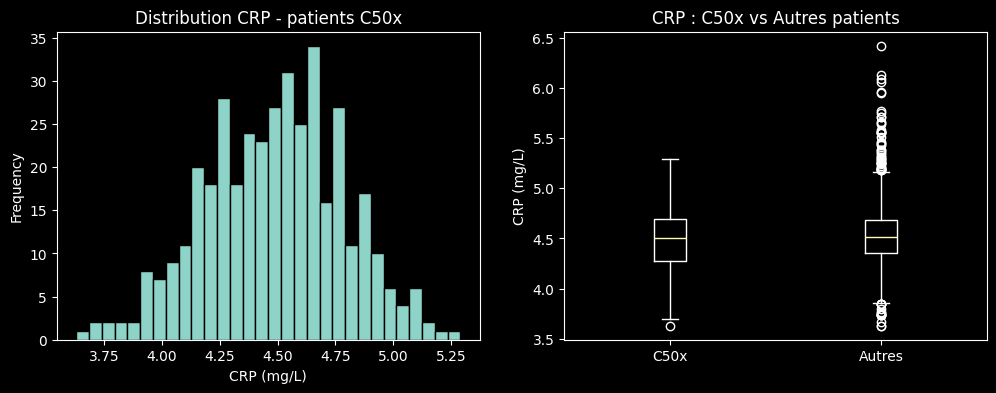

In [21]:


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
df_crp_c50['transformed_value'].plot.hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution CRP - patients C50x')
axes[0].set_xlabel('CRP (mg/L)')





plt.boxplot(
    [df_crp_c50['transformed_value'], df_crp_autres['transformed_value']],
    labels=['C50x', 'Autres']
)
plt.ylabel('CRP (mg/L)')
plt.title('CRP : C50x vs Autres patients')
plt.show()


In [22]:
df_crp_c50['groupe'] = 'C50x'
df_crp_autres['groupe'] = 'Autres'
df_compare = pd.concat([df_crp_c50, df_crp_autres])


alt.Chart(df_compare).mark_boxplot().encode(
    x=alt.X('groupe:N', title='Groupe'),
    y=alt.Y('transformed_value:Q', title='CRP (mg/L)'),
    color='groupe:N'
).properties(
    title='CRP : C50x vs Autres patients',
    width=300
)

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/2765715794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_crp_c50['groupe'] = 'C50x'
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/2765715794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_crp_autres['groupe'] = 'Autres'


alt.Chart(...)

In [23]:
# Patients uniques avec leur groupe et sexe
df_patients = df_compare.drop_duplicates('person_id')[['person_id', 'gender_source_value', 'groupe']]

# --- 1. Tableau croisé sexe × groupe ---
tableau = pd.crosstab(
    df_patients['gender_source_value'],
    df_patients['groupe'],
    margins=True
)
print(tableau)



groupe               Autres  C50x   All
gender_source_value                    
female                  560   393   953
male                    541     0   541
All                    1101   393  1494


In [24]:
# Visualisation Altair 
repartition = df_patients.groupby(['gender_source_value', 'groupe']).size().reset_index(name='nb_patients')

alt.Chart(repartition).mark_bar().encode(
    x=alt.X('gender_source_value:N', title='Sexe'),
    y=alt.Y('nb_patients:Q', title='Nombre de patients'),
    color=alt.Color('groupe:N', scale=alt.Scale(
        domain=['C50x', 'Autres'],
        range=['#e45756', '#4c78a8']
    )),
    xOffset='groupe:N'
).properties(
    title='Influence du sexe sur la présence en C50x',
    width=300
)


alt.Chart(...)

In [25]:
#  Test Chi² 
from scipy.stats import chi2_contingency

table = pd.crosstab(df_patients['gender_source_value'], df_patients['groupe'])
chi2, p, dof, _ = chi2_contingency(table)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4f}")
print("→ Lien significatif entre sexe et C50x" if p < 0.05 else "→ Pas de lien significatif")


Chi² = 300.610, p-value = 0.0000
→ Lien significatif entre sexe et C50x


In [ ]:
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504', 'C500']

df_bmi_c50 = df_analyse[
    (df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == 'bmi')
]

df_bmi_autres = df_analyse[
    (~df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == 'bmi')
]

tableau_stats = pd.DataFrame({
    'C50x': df_bmi_c50['transformed_value'].describe(),
    'Autres': df_bmi_autres['transformed_value'].describe()
})

tableau_stats.loc['patients_uniques'] = [
    df_bmi_c50['person_id'].nunique(),
    df_bmi_autres['person_id'].nunique()
]

tableau_stats

In [27]:
df_bmi_c50['groupe'] = 'C50x'
df_bmi_autres['groupe'] = 'Autres'
df_compare = pd.concat([df_bmi_c50, df_bmi_autres])

alt.Chart(df_compare).mark_boxplot().encode(
    x=alt.X('groupe:N', title='Groupe'),
    y=alt.Y('transformed_value:Q', title='BMI (kg/m²)'),
    color='groupe:N'
).properties(
    title='BMI : C50x vs Autres patients',
    width=300
)

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/3686651211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bmi_c50['groupe'] = 'C50x'
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/3686651211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bmi_autres['groupe'] = 'Autres'


alt.Chart(...)

In [ ]:
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504', 'C500']
biomarqueurs = ['crp', 'bmi', 'urea', 'hb']

def analyser_biomarqueur(df_analyse, concept, codes_cibles):
    df_c50 = df_analyse[
        (df_analyse['condition_source_value'].isin(codes_cibles)) &
        (df_analyse['concept_source_value'] == concept)
    ]
    df_autres = df_analyse[
        (~df_analyse['condition_source_value'].isin(codes_cibles)) &
        (df_analyse['concept_source_value'] == concept)
    ]
    
    tableau = pd.DataFrame({
        'C50x': df_c50['transformed_value'].describe(),
        'Autres': df_autres['transformed_value'].describe()
    })
    tableau.loc['patients_uniques'] = [
        df_c50['person_id'].nunique(),
        df_autres['person_id'].nunique()
    ]
    
    return df_c50, df_autres, tableau


resultats = {}
for concept in biomarqueurs:
    print(f"\n{'='*60}")
    print(f"ANALYSE : {concept.upper()}")
    print(f"{'='*60}")
    
    df_c50, df_autres, tableau = analyser_biomarqueur(df_analyse, concept, codes_cibles)
    print(tableau)
    
    resultats[concept] = {
        'df_c50': df_c50,
        'df_autres': df_autres,
        'tableau': tableau
    }
    
   

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/2347021364.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/2347021364.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/2347021364.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_52275/2347021364.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels

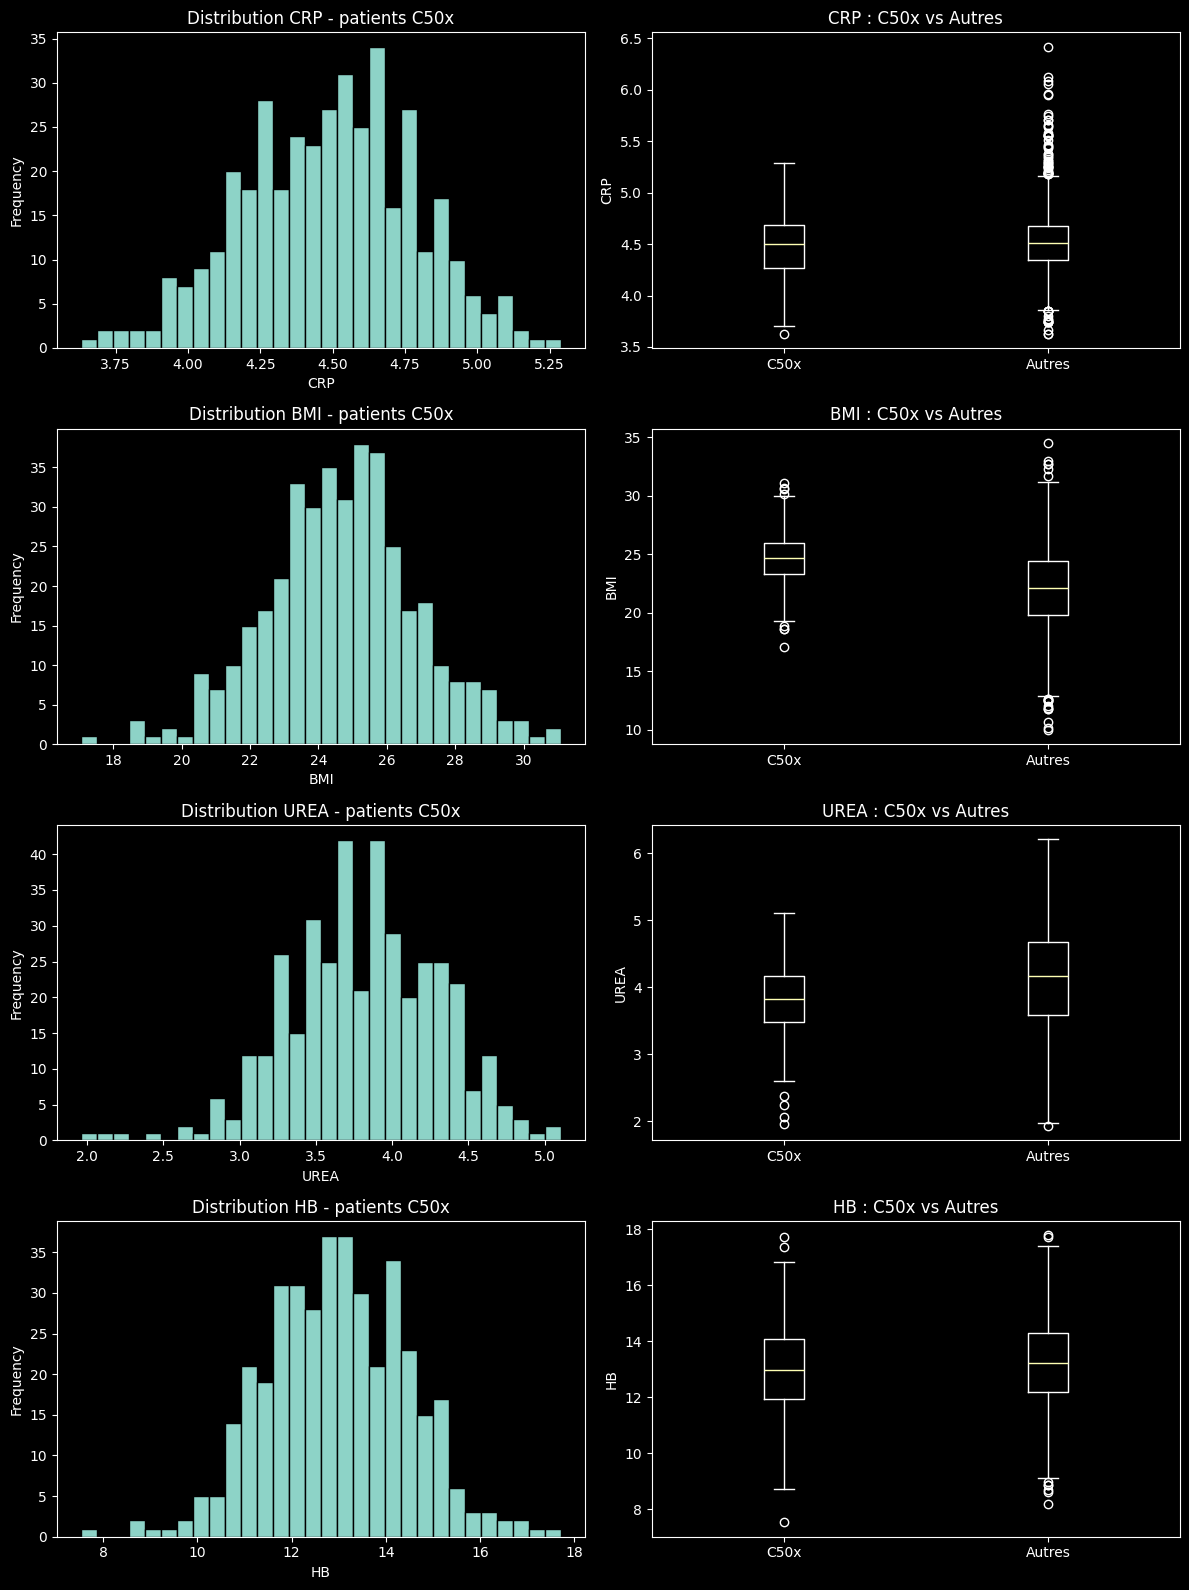

In [36]:
fig, axes = plt.subplots(len(biomarqueurs), 2, figsize=(12, 4*len(biomarqueurs)))

for i, concept in enumerate(biomarqueurs):
    df_c50 = resultats[concept]['df_c50']
    df_autres = resultats[concept]['df_autres']
    
    df_c50['transformed_value'].plot.hist(bins=30, ax=axes[i, 0], edgecolor='black')
    axes[i, 0].set_title(f'Distribution {concept.upper()} - patients C50x')
    axes[i, 0].set_xlabel(concept.upper())
    
    axes[i, 1].boxplot(
        [df_c50['transformed_value'], df_autres['transformed_value']],
        labels=['C50x', 'Autres']
    )
    axes[i, 1].set_ylabel(concept.upper())
    axes[i, 1].set_title(f'{concept.upper()} : C50x vs Autres')

plt.tight_layout()
plt.show()

In [37]:
df_compare_all = pd.concat([
    pd.concat([
        resultats[concept]['df_c50'].assign(groupe='C50x', concept_label=concept.upper()),
        resultats[concept]['df_autres'].assign(groupe='Autres', concept_label=concept.upper())
    ])
    for concept in biomarqueurs
])

alt.Chart(df_compare_all).mark_boxplot().encode(
    x=alt.X('groupe:N', title='Groupe'),
    y=alt.Y('transformed_value:Q', title='Valeur'),
    color='groupe:N',
    column=alt.Column('concept_label:N', title='Biomarqueur')
).properties(
    width=150,
    title='Comparaison biomarqueurs : C50x vs Autres'
).resolve_scale(y='independent')

alt.Chart(...)